# <center style="font-weight: bold; color: #0098cd;">Transcripción automática del habla (ASR)</center>

## 1. Introducción

### 1.1 Objetivo

### 1.2 Contexto dentro del sistema completo

### 1.3 Requisitos de esta fase

## 2. Preparación del entorno de trabajo

En esta sección se define el entorno técnico necesario para el desarrollo del pipeline de preprocesamiento de audio. Se incluyen la instalación de dependencias, la importación de librerías especializadas y la configuración de rutas de trabajo.

El objetivo es garantizar un entorno reproducible y estructurado que permita ejecutar el flujo completo de procesamiento sobre diferentes conjuntos de datos sin modificaciones en la lógica del código. Asimismo, se establece una organización clara de los directorios que facilita la separación entre datos originales, datos intermedios y resultados finales.

### 2.1 Instalación de dependencias

En este apartado se especifica la instalación de las librerías necesarias para la ejecución del *notebook*. Todas las dependencias se gestionan mediante un archivo `requirements.txt`, lo que permite replicar el entorno de ejecución de forma controlada y consistente.

#### 2.1.1 Configuración del entorno

Este notebook requiere la instalación previa de las dependencias del proyecto.

Ejecutar en terminal:

```bash
pip install -r requirements.txt

### 2.2 Importación de librerías

In [1]:
# ==============================
# Gestión de rutas y sistema
# ==============================
from pathlib import Path                    # gestión de rutas
import os                                   # operaciones del sistema
import json                                 # lectura/escritura JSON

# ==============================
# Procesamiento de audio
# ==============================
import soundfile as sf                      # lectura/escritura de audio
import librosa                              # procesamiento de audio
import numpy as np                          # operaciones numéricas sobre señal

# ==============================
# Modelos de IA (ASR)
# ==============================
from faster_whisper import WhisperModel     # modelo ASR Whisper optimizado

# ==============================
# Evaluación de modelos
# ==============================
from jiwer import wer, cer, process_words   # métricas WER/CER y alineación

# ==============================
# Manipulación de datos
# ==============================
import pandas as pd                         # datos tabulares
from collections import Counter             # conteo de frecuencias

# ==============================
# Procesamiento de texto
# ==============================
import re                                   # expresiones regulares
import unicodedata                          # normalización de texto
from num2words import num2words             # conversión de números a texto

# ==============================
# Visualización y análisis
# ==============================
import matplotlib.pyplot as plt             # visualización de datos
import seaborn as sns                       # visualización estadística

# ==============================
# Utilidades y control
# ==============================
from tqdm import tqdm                       # barra de progreso
import time                                 # medición de tiempo

/Volumes/EXTENSION/GitHub/TFM/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.3 Gestión y configuración de rutas

In [5]:
# Detectar raíz
project_root = Path.cwd()

while not (project_root / "data").exists():
    project_root = project_root.parent


# =========================
# DIRECTORIOS
# =========================

# Ruta raíz del proyecto
data_dir = project_root / "data"


# =========================
# CONFIGURACIÓN (DOMINIO)
# =========================

# Ruta al JSON de términos de dominio
domain_terms_path = data_dir / "config" / "domain" / "coffee_cacao_terms.json"


# =========================
# AUDIOS
# =========================

# Carpeta base de audios
audio_dir = data_dir / "audio"

# Baseline (audios estandarizados)
standardized_audio_dir = audio_dir / "standardized"

# Pipeline final (audios procesados)
processed_audio_dir = audio_dir / "processed"

# Audios en crudo
raw_audio_dir = audio_dir / "raw"


# =========================
# TRANSCRIPCIONES
# =========================

# Carpeta general de transcripciones
transcriptions_dir = data_dir / "transcriptions"

# Salida final del ASR
asr_output_dir = transcriptions_dir / "asr_output"

# Predicciones del ASR (experimentos)
predictions_dir = transcriptions_dir / "predictions"

# Ground truth (transcripciones manuales)
ground_truth_dir = transcriptions_dir / "ground_truth"


# =========================
# CREACIÓN DE CARPETAS
# =========================

asr_output_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)
ground_truth_dir.mkdir(parents=True, exist_ok=True)


# =========================
# VERIFICACIÓN
# =========================

print("Ruta raíz:", project_root)

print("\n--- Configuración ---")
print("Términos de dominio:", domain_terms_path)

print("\n--- Audios ---")
print("Raw:", raw_audio_dir)
print("Baseline (standardized):", standardized_audio_dir)
print("Pipeline final (processed):", processed_audio_dir)

print("\n--- Transcripciones ---")
print("Salida ASR:", asr_output_dir)
print("Predicciones (experimentos):", predictions_dir)
print("Ground truth:", ground_truth_dir)

Ruta raíz: /Volumes/EXTENSION/GitHub/TFM

--- Configuración ---
Términos de dominio: /Volumes/EXTENSION/GitHub/TFM/data/config/domain/coffee_cacao_terms.json

--- Audios ---
Raw: /Volumes/EXTENSION/GitHub/TFM/data/audio/raw
Baseline (standardized): /Volumes/EXTENSION/GitHub/TFM/data/audio/standardized
Pipeline final (processed): /Volumes/EXTENSION/GitHub/TFM/data/audio/processed

--- Transcripciones ---
Salida ASR: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/asr_output
Predicciones (experimentos): /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/predictions
Ground truth: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/ground_truth


## 3. Preparación del *dataset* para ASR

### 3.1 Carga de audios preprocesados

In [6]:
# Carga de rutas de audios baseline (estandarizados)
audio_paths_standardized = sorted(list(standardized_audio_dir.glob("*.wav")))

# Carga de rutas de audios procesados (pipeline final)
audio_paths_processed = sorted(list(processed_audio_dir.glob("*.wav")))

# Verificación
print(f"Audios baseline (standardized): {len(audio_paths_standardized)}")
print(f"Audios pipeline final (processed): {len(audio_paths_processed)}")

Audios baseline (standardized): 11
Audios pipeline final (processed): 11


### 3.2 Asociación con metadatos

In [7]:
# Construcción de dataset baseline (audios estandarizados)
dataset_standardized = [
    {"audio_id": path.stem, "path": path}
    for path in audio_paths_standardized
]

# Construcción de dataset procesado (pipeline final)
dataset_processed = [
    {"audio_id": path.stem, "path": path}
    for path in audio_paths_processed
]

# Conversión a DataFrame para inspección
df_standardized = pd.DataFrame(dataset_standardized)
df_processed = pd.DataFrame(dataset_processed)

pd.DataFrame({
    "standardized": df_standardized["audio_id"].head(),
    "processed": df_processed["audio_id"].head()
})

,standardized,processed
0,AUDIO-2025-09-18-13-34-03,AUDIO-2025-09-18-13-34-03
1,AUDIO-2026-03-12-09-54-36,AUDIO-2026-03-12-09-54-36
2,AUDIO-2026-04-21-17-26-57,AUDIO-2026-04-21-17-26-57
3,AUDIO-2026-04-22-11-23-01,AUDIO-2026-04-22-11-23-01
4,AUDIO-2026-04-22-11-24-06,AUDIO-2026-04-22-11-24-06


### 3.3 Validación de entradas para transcripción

#### 3.3.1 Verificación de formato (wav, 16kHz, mono)

In [8]:
# Validación de audios baseline (estandarizados)
for item in dataset_standardized:
    try:
        info = sf.info(item["path"])
        item["samplerate"] = info.samplerate
        item["channels"] = info.channels
        item["format_ok"] = (info.samplerate == 16000 and info.channels == 1)
    except Exception as e:
        item["format_ok"] = False
        item["error"] = str(e)


# Validación de audios procesados (pipeline final)
for item in dataset_processed:
    try:
        info = sf.info(item["path"])
        item["samplerate"] = info.samplerate
        item["channels"] = info.channels
        item["format_ok"] = (info.samplerate == 16000 and info.channels == 1)
    except Exception as e:
        item["format_ok"] = False
        item["error"] = str(e)

#### 3.3.2 Control de errores y audios inválidos

In [9]:
# Filtrado baseline (audios estandarizados)
valid_standardized = [item for item in dataset_standardized if item["format_ok"]]
invalid_standardized = [item for item in dataset_standardized if not item["format_ok"]]

print(f"Standardized → válidos: {len(valid_standardized)}, inválidos: {len(invalid_standardized)}")


# Filtrado pipeline final (audios procesados)
valid_processed = [item for item in dataset_processed if item["format_ok"]]
invalid_processed = [item for item in dataset_processed if not item["format_ok"]]

print(f"Processed → válidos: {len(valid_processed)}, inválidos: {len(invalid_processed)}")


# Mostrar errores si existen
if invalid_standardized or invalid_processed:
    print("\nEjemplos de errores:")
    
    for item in (invalid_standardized + invalid_processed)[:5]:
        print(f"- {item['audio_id']}: {item.get('error', 'Formato incorrecto')}")

Standardized → válidos: 11, inválidos: 0
Processed → válidos: 11, inválidos: 0


## 4. Configuración del modelo ASR

### 4.1 Selección del modelo base (Whisper)

In [10]:
# Selección del tamaño del modelo
model_size = "medium"  # opciones: tiny, base, small, medium, large-v3

# Configuración de dispositivo (ajusta según tu equipo)
device = "cpu"   # "cuda" si tienes GPU
compute_type = "int8"  # "float16" en GPU, "int8" en CPU

# Carga del modelo
model = WhisperModel(model_size, device=device, compute_type=compute_type)

print(f"Modelo cargado: {model_size}")

Modelo cargado: medium


### 4.2 Parámetros de inferencia

In [11]:
asr_params = {
    "language": "es",                       # fuerza el idioma español, evitando autodetección y posibles errores de idioma
    "beam_size": 1,                         # número de hipótesis evaluadas; 1 = decodificación greedy (rápida y casi determinista)
    "condition_on_previous_text": False,    # evita usar contexto previo entre segmentos, reduciendo propagación de errores
    "word_timestamps": False,               # desactiva timestamps por palabra (innecesario si solo quieres texto)
    "temperature": 0.0                      # desactiva aleatoriedad para resultados consistentes
}

### 4.3 Definición de configuración *baseline*

In [12]:
# Configuración baseline utilizada en la transcripción

baseline_config = {
    "model_size": model_size,
    "device": device,
    "compute_type": compute_type,
    "asr_params": asr_params
}

print("Configuración baseline:")
display(baseline_config)

Configuración baseline:


{'model_size': 'medium',
 'device': 'cpu',
 'compute_type': 'int8',
 'asr_params': {'language': 'es',
  'beam_size': 1,
  'condition_on_previous_text': False,
  'word_timestamps': False,
  'temperature': 0.0}}

## 5. Transcripción automática del audio

INTRO AQUI

### 5.1 Generación de transcripciones (*baseline*)

In [13]:
# Transcripción baseline (audios estandarizados)
results_standardized = []

for item in tqdm(dataset_standardized):
    segments, _ = model.transcribe(
        str(item["path"]),
        **asr_params
    )
    
    text = " ".join([seg.text for seg in segments]).strip()
    
    results_standardized.append({
        "audio_id": item["audio_id"],
        "text": text
    })


# Transcripción pipeline final (audios procesados)
results_processed = []

for item in tqdm(dataset_processed):
    segments, _ = model.transcribe(
        str(item["path"]),
        **asr_params
    )
    
    text = " ".join([seg.text for seg in segments]).strip()
    
    results_processed.append({
        "audio_id": item["audio_id"],
        "text": text
    })

100%|██████████| 11/11 [02:13<00:00, 12.10s/it]


### 5.2 Almacenamiento estructurado de resultados

Antes de ejecutar este bloque, se recomienda limpiar manualmente los directorios de salida para evitar inconsistencias entre ejecuciones.

In [15]:
# Guardado baseline (audios estandarizados)
for item in results_standardized:
    output_path = predictions_dir / "standardized" / f"{item['audio_id']}.json"
    
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(item, f, ensure_ascii=False, indent=2)


# Guardado pipeline final (audios procesados)
for item in results_processed:
    output_path = predictions_dir / "processed" / f"{item['audio_id']}.json"
    
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(item, f, ensure_ascii=False, indent=2)

Las transcripciones generadas se almacenan en formato JSON, donde cada archivo representa un audio procesado. La estructura contiene el identificador del audio (`audio_id`) y el texto transcrito (`text`), facilitando su posterior uso en el cálculo de métricas y en las etapas de procesamiento del lenguaje natural.

Ejemplo:

```json
{
  "audio_id": "001",
  "text": "aplique fungicida en lote 3"
}
```

### 5.3 Verificación de transcripciones generadas

In [16]:
# Ejemplo de verificación

if results_standardized:
    print(results_standardized[0])

if results_processed:
    print(results_processed[0])

{'audio_id': 'AUDIO-2025-09-18-13-34-03', 'text': 'Buenas José Manuel, mandame porfa si puedes algún teléfono de aquí de Ciuri o del encargado o del alcalde  o de alguien de aquí porfa'}
{'audio_id': 'AUDIO-2025-09-18-13-34-03', 'text': 'Buenas José Manuel, mandame porfa si puedes algún teléfono de aquí de Ciuri o del encargado o del alcalde  o de alguien de aquí porfa'}


### 5.4 Control de errores

In [17]:
# Detección de textos vacíos en baseline
empty_standardized = [r for r in results_standardized if not r["text"].strip()]

# Detección de textos vacíos en pipeline final
empty_processed = [r for r in results_processed if not r["text"].strip()]

print(f"Baseline → textos vacíos: {len(empty_standardized)}")
print(f"Processed → textos vacíos: {len(empty_processed)}")

# Mostrar ejemplos si existen
if empty_standardized or empty_processed:
    print("\nEjemplos de audios con transcripción vacía:")
    
    for r in (empty_standardized + empty_processed)[:5]:
        print(f"- {r['audio_id']}")

Baseline → textos vacíos: 0
Processed → textos vacíos: 0


## 6. Evaluación del rendimiento del ASR

### 6.1 Definición del conjunto de referencia (*ground truth*)

In [18]:
# Carga del archivo CSV de ground truth
df_gt = pd.read_csv(ground_truth_dir / "ground_truth.csv")

# Eliminamos posibles filas con valores nulos
df_gt = df_gt.dropna(subset=["audio_id", "transcripcion"])

# Verificamos que no existan identificadores duplicados
assert df_gt["audio_id"].is_unique, "Error: existen audio_id duplicados en el ground truth"

# Construcción del diccionario {audio_id: transcripcion}
ground_truth = dict(zip(df_gt["audio_id"], df_gt["transcripcion"]))

print(f"Total ground truth: {len(ground_truth)}")

Total ground truth: 11


### 6.2 Normalización previa de texto

esto se hace para...

In [19]:
# Función para normalizar texto antes de calcular métricas ASR
def normalize_text(text):
    
    # Conversión a minúsculas
    text = text.lower()
    
    # Conversión de números enteros a texto
    def replace_number(match):
        try:
            num = int(match.group())
            return num2words(num, lang='es')
        except:
            return match.group()
    
    text = re.sub(r"\b\d+\b", replace_number, text)
    
    # Eliminación de acentos
    text = ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )
    
    # Eliminación de puntuación
    text = re.sub(r"[^\w\s]", "", text)
    
    # Normalización de espacios
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

### 6.3 Cálculo de métricas

INTRO AQUI

#### 6.3.1 *Word Error Rate* (WER)

In [20]:
# Función para calcular el Word Error Rate (WER) para un conjunto de resultados
def compute_wer(results, ground_truth):
    
    # Lista donde se almacenan los valores individuales de WER por audio
    scores = []
    
    # Iteramos sobre cada transcripción generada por el ASR
    for item in results:
        
        # Identificador único del audio
        audio_id = item["audio_id"]
        
        # Verificamos que exista referencia en el conjunto ground truth
        if audio_id in ground_truth:
            
            # Texto de referencia (transcripción manual)
            ref = ground_truth[audio_id]
            
            # Texto predicho por el modelo ASR
            hyp = item["text"]
            
            # Aplicamos la normalización para eliminar diferencias no relevantes
            ref = normalize_text(ref)
            hyp = normalize_text(hyp)
            
            # Evitamos casos vacíos tras normalización
            if ref and hyp:
                
                # Cálculo del WER entre referencia y predicción
                score = wer(ref, hyp)
                
                # Almacenamiento del resultado individual
                scores.append(score)
    
    # Devolvemos la lista completa de errores
    return scores

#### 6.3.2 *Character Error Rate* (CER)

In [21]:
# Función para calcular el Character Error Rate (CER) para un conjunto de resultados
def compute_cer(results, ground_truth):
    
    # Lista donde se almacenan los valores individuales de CER por audio
    scores = []
    
    # Iteramos sobre cada transcripción generada por el ASR
    for item in results:
        
        # Identificador único del audio
        audio_id = item["audio_id"]
        
        # Verificamos que exista referencia en el conjunto ground truth
        if audio_id in ground_truth:
            
            # Texto de referencia (transcripción manual)
            ref = ground_truth[audio_id]
            
            # Texto predicho por el modelo ASR
            hyp = item["text"]
            
            # Aplicamos la misma normalización que en WER para mantener coherencia
            ref = normalize_text(ref)
            hyp = normalize_text(hyp)
            
            # Evitamos casos vacíos tras normalización
            if ref and hyp:
                
                # Cálculo del CER entre referencia y predicción
                score = cer(ref, hyp)
                
                # Almacenamiento del resultado individual
                scores.append(score)
    
    # Devolvemos la lista completa de errores
    return scores

### 6.4 Evaluación cuantitativa

In [25]:
# =========================
# CÁLCULO DE MÉTRICAS
# =========================

# Cálculo explícito (base del análisis)
wer_standardized = compute_wer(results_standardized, ground_truth)
wer_processed = compute_wer(results_processed, ground_truth)

cer_standardized = compute_cer(results_standardized, ground_truth)
cer_processed = compute_cer(results_processed, ground_truth)


# =========================
# DATASET BASE
# =========================

# Identificadores
ids_std = [r["audio_id"] for r in results_standardized]

# Construcción del DataFrame base
df_results = pd.DataFrame({
    "audio_id": ids_std,
    "wer_standardized": wer_standardized,
    "wer_processed": wer_processed,
    "cer_standardized": cer_standardized,
    "cer_processed": cer_processed
})


# =========================
# ESTADÍSTICAS
# =========================

# Calcula estadísticas descriptivas robustas
def compute_robust_stats(values: list[float]) -> dict:
    
    arr = np.array(values)
    arr_sorted = np.sort(arr)
    
    n = len(arr_sorted)
    k = int(0.1 * n)
    
    trimmed = arr_sorted[k:n-k] if n > 2 * k else arr_sorted
    
    return {
        "mean": np.mean(arr),
        "median": np.median(arr),
        "std": np.std(arr),
        "min": np.min(arr),
        "max": np.max(arr),
        "p90": np.percentile(arr, 90),
        "p95": np.percentile(arr, 95),
        "trimmed_mean": np.mean(trimmed)
    }


# =========================
# APLICACIÓN DE ESTADÍSTICAS
# =========================

stats_wer_standardized = compute_robust_stats(df_results["wer_standardized"])
stats_wer_processed = compute_robust_stats(df_results["wer_processed"])

stats_cer_standardized = compute_robust_stats(df_results["cer_standardized"])
stats_cer_processed = compute_robust_stats(df_results["cer_processed"])


# =========================
# VISUALIZACIÓN
# =========================

df_stats = pd.DataFrame([
    {"metric": "WER", "pipeline": "standardized", **stats_wer_standardized},
    {"metric": "WER", "pipeline": "processed", **stats_wer_processed},
    {"metric": "CER", "pipeline": "standardized", **stats_cer_standardized},
    {"metric": "CER", "pipeline": "processed", **stats_cer_processed},
])

display(df_stats)

,metric,pipeline,mean,median,std,min,max,p90,p95,trimmed_mean
0,WER,standardized,0.063035,0.033333,0.053274,0.0,0.173913,0.122172,0.148042,0.057719
1,WER,processed,0.062362,0.040741,0.050697,0.0,0.173913,0.109589,0.141751,0.056897
2,CER,standardized,0.031638,0.014118,0.029485,0.0,0.088235,0.073469,0.080852,0.028865
3,CER,processed,0.031786,0.025678,0.027412,0.0,0.088235,0.073469,0.080852,0.029045


### 6.4 Análisis de resultados globales

In [26]:
# =========================
# VALIDACIÓN DE CONSISTENCIA
# =========================

# Verificamos que los audio_id estén alineados entre ambos pipelines
ids_std = [r["audio_id"] for r in results_standardized]
ids_proc = [r["audio_id"] for r in results_processed]

assert ids_std == ids_proc, "Error: los audio_id no están alineados"


# =========================
# ENRIQUECIMIENTO DEL DATASET
# =========================

# Diferencia de error entre pipelines (processed vs standardized)
df_results["delta_wer"] = df_results["wer_processed"] - df_results["wer_standardized"]
df_results["delta_cer"] = df_results["cer_processed"] - df_results["cer_standardized"]


# =========================
# CLASIFICACIÓN DE RESULTADOS
# =========================

# Clasificación del impacto del procesamiento
df_results["wer_estado"] = df_results["delta_wer"].apply(
    lambda x: "mejora" if x < 0 else ("empeora" if x > 0 else "igual")
)

df_results["cer_estado"] = df_results["delta_cer"].apply(
    lambda x: "mejora" if x < 0 else ("empeora" if x > 0 else "igual")
)


# =========================
# RESUMEN GLOBAL
# =========================

wer_summary = df_results["wer_estado"].value_counts(normalize=True) * 100
cer_summary = df_results["cer_estado"].value_counts(normalize=True) * 100

print("Distribución WER:")
for estado, valor in wer_summary.items():
    print(f"{estado}: {valor:.2f}%")

print("\nDistribución CER:")
for estado, valor in cer_summary.items():
    print(f"{estado}: {valor:.2f}%")


# =========================
# ANÁLISIS DE CASOS
# =========================

# Mejores y peores casos (WER)
df_best_wer = df_results[df_results["wer_estado"] == "mejora"].sort_values(by="delta_wer")
df_worst_wer = df_results[df_results["wer_estado"] == "empeora"].sort_values(by="delta_wer", ascending=False)

print("\nTop mejoras (WER):")
display(df_best_wer.head(10))

print("\nPeores casos (WER):")
display(df_worst_wer.head(10))


# Mejores y peores casos (CER)
df_best_cer = df_results[df_results["cer_estado"] == "mejora"].sort_values(by="delta_cer")
df_worst_cer = df_results[df_results["cer_estado"] == "empeora"].sort_values(by="delta_cer", ascending=False)

print("\nTop mejoras (CER):")
display(df_best_cer.head(10))

print("\nPeores casos (CER):")
display(df_worst_cer.head(10))


# =========================
# VISIÓN GENERAL
# =========================

print("\nVisión general:")
display(df_results)

Distribución WER:
igual: 63.64%
empeora: 27.27%
mejora: 9.09%

Distribución CER:
igual: 45.45%
empeora: 27.27%
mejora: 27.27%

Top mejoras (WER):


,audio_id,wer_standardized,wer_processed,cer_standardized,cer_processed,delta_wer,delta_cer,wer_estado,cer_estado
7,AUDIO-2026-04-25-10-36-43,0.122172,0.085973,0.064306,0.038211,-0.036199,-0.026095,mejora,mejora



Peores casos (WER):


,audio_id,wer_standardized,wer_processed,cer_standardized,cer_processed,delta_wer,delta_cer,wer_estado,cer_estado
6,AUDIO-2026-04-25-10-36-13,0.095890,0.109589,0.036685,0.048913,0.013699,0.012228,empeora,empeora
2,AUDIO-2026-04-21-17-26-57,0.015385,0.023077,0.011412,0.025678,0.007692,0.014265,empeora,empeora
9,AUDIO-2026-04-25-10-37-58,0.033333,0.040741,0.013524,0.012772,0.007407,-0.000751,empeora,mejora



Top mejoras (CER):


,audio_id,wer_standardized,wer_processed,cer_standardized,cer_processed,delta_wer,delta_cer,wer_estado,cer_estado
7,AUDIO-2026-04-25-10-36-43,0.122172,0.085973,0.064306,0.038211,-0.036199,-0.026095,mejora,mejora
8,AUDIO-2026-04-25-10-37-29,0.090000,0.090000,0.036660,0.034623,0.000000,-0.002037,igual,mejora
9,AUDIO-2026-04-25-10-37-58,0.033333,0.040741,0.013524,0.012772,0.007407,-0.000751,empeora,mejora



Peores casos (CER):


,audio_id,wer_standardized,wer_processed,cer_standardized,cer_processed,delta_wer,delta_cer,wer_estado,cer_estado
2,AUDIO-2026-04-21-17-26-57,0.015385,0.023077,0.011412,0.025678,0.007692,0.014265,empeora,empeora
6,AUDIO-2026-04-25-10-36-13,0.095890,0.109589,0.036685,0.048913,0.013699,0.012228,empeora,empeora
4,AUDIO-2026-04-22-11-24-06,0.014388,0.014388,0.006684,0.010695,0.000000,0.004011,igual,empeora



Visión general:


,audio_id,wer_standardized,wer_processed,cer_standardized,cer_processed,delta_wer,delta_cer,wer_estado,cer_estado
0,AUDIO-2025-09-18-13-34-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,igual,igual
1,AUDIO-2026-03-12-09-54-36,0.098039,0.098039,0.073469,0.073469,0.000000,0.000000,igual,igual
2,AUDIO-2026-04-21-17-26-57,0.015385,0.023077,0.011412,0.025678,0.007692,0.014265,empeora,empeora
3,AUDIO-2026-04-22-11-23-01,0.173913,0.173913,0.088235,0.088235,0.000000,0.000000,igual,igual
4,AUDIO-2026-04-22-11-24-06,0.014388,0.014388,0.006684,0.010695,0.000000,0.004011,igual,empeora
5,AUDIO-2026-04-25-10-35-47,0.028986,0.028986,0.002928,0.002928,0.000000,0.000000,igual,igual
6,AUDIO-2026-04-25-10-36-13,0.095890,0.109589,0.036685,0.048913,0.013699,0.012228,empeora,empeora
7,AUDIO-2026-04-25-10-36-43,0.122172,0.085973,0.064306,0.038211,-0.036199,-0.026095,mejora,mejora
8,AUDIO-2026-04-25-10-37-29,0.090000,0.090000,0.036660,0.034623,0.000000,-0.002037,igual,mejora
9,AUDIO-2026-04-25-10-37-58,0.033333,0.040741,0.013524,0.012772,0.007407,-0.000751,empeora,mejora


## 7. Análisis de errores de transcripción

### 7.1 Identificación de errores frecuentes

#### 7.1.1 Sustituciones

In [27]:
# Función para obtener las sustituciones más frecuentes
def get_substitutions(results, ground_truth):
    
    subs = Counter()
    
    for item in results:
        audio_id = item["audio_id"]
        
        if audio_id in ground_truth:
            
            # Normalización coherente con WER/CER
            ref = normalize_text(ground_truth[audio_id])
            hyp = normalize_text(item["text"])
            
            if ref and hyp:
                
                ref_words = ref.split()
                hyp_words = hyp.split()
                
                alignment = process_words(ref, hyp)
                
                for group in alignment.alignments:
                    for chunk in group:
                        
                        if chunk.type == "substitute":
                            
                            ref_segment = ref_words[chunk.ref_start_idx:chunk.ref_end_idx]
                            hyp_segment = hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx]
                            
                            # FILTRO CLAVE: solo sustituciones 1 a 1 (palabra a palabra)
                            if len(ref_segment) == 1 and len(hyp_segment) == 1:
                                
                                ref_word = ref_segment[0]
                                hyp_word = hyp_segment[0]
                                
                                subs[(ref_word, hyp_word)] += 1
    
    return subs


# Cálculo
subs_standardized = get_substitutions(results_standardized, ground_truth)
subs_processed = get_substitutions(results_processed, ground_truth)


# Visualización
print("Sustituciones más frecuentes (filtradas):")

print("\nStandardized:")
for (ref, hyp), count in subs_standardized.most_common(10):
    print(f"{ref} → {hyp} ({count})")

print("\nProcessed:")
for (ref, hyp), count in subs_processed.most_common(10):
    print(f"{ref} → {hyp} ({count})")

Sustituciones más frecuentes (filtradas):

Standardized:
miga → amiga (2)
llamado → damos (1)
alejarme → dejarme (1)
turrialba → rurea (1)
taladro → taladron (1)
chulo → chuno (1)
medio → mediodia (1)
logrono → grono (1)
he → estaba (1)
te → si (1)

Processed:
miga → amiga (2)
llamado → damos (1)
alejarme → dejarme (1)
taladro → taladron (1)
medio → mediodia (1)
logrono → grono (1)
he → estaba (1)
aquello → aqui (1)
te → si (1)
les → le (1)


#### 7.1.2 Inserciones

In [28]:
# Función para calcular las inserciones más frecuentes
def get_insertions(results, ground_truth):
    
    ins = Counter()
    
    for item in results:
        audio_id = item["audio_id"]
        
        if audio_id in ground_truth:
            
            # Normalización coherente
            ref = normalize_text(ground_truth[audio_id])
            hyp = normalize_text(item["text"])
            
            if ref and hyp:
                
                hyp_words = hyp.split()
                
                alignment = process_words(ref, hyp)
                
                for group in alignment.alignments:
                    for chunk in group:
                        
                        if chunk.type == "insert":
                            
                            hyp_segment = hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx]
                            
                            # FILTRO: solo palabras individuales
                            if len(hyp_segment) == 1:
                                
                                hyp_word = hyp_segment[0]
                                
                                ins[hyp_word] += 1
    
    return ins


# Cálculo
ins_standardized = get_insertions(results_standardized, ground_truth)
ins_processed = get_insertions(results_processed, ground_truth)


# Visualización
print("Inserciones más frecuentes (filtradas):")

print("\nStandardized:")
for word, count in ins_standardized.most_common(10):
    print(f"{word} ({count})")

print("\nProcessed:")
for word, count in ins_processed.most_common(10):
    print(f"{word} ({count})")

Inserciones más frecuentes (filtradas):

Standardized:
lo (1)
no (1)
y (1)
a (1)
tenia (1)
rey (1)
de (1)
logrona (1)
que (1)

Processed:
lo (2)
hay (1)
no (1)
de (1)
logrona (1)
ha (1)


#### 7.1.3 Eliminaciones

In [29]:
# Función para calcular las eliminaciones más frecuentes
def get_deletions(results, ground_truth):
    
    dels = Counter()
    
    for item in results:
        audio_id = item["audio_id"]
        
        if audio_id in ground_truth:
            
            # Normalización coherente
            ref = normalize_text(ground_truth[audio_id])
            hyp = normalize_text(item["text"])
            
            if ref and hyp:
                
                ref_words = ref.split()
                
                alignment = process_words(ref, hyp)
                
                for group in alignment.alignments:
                    for chunk in group:
                        
                        if chunk.type == "delete":
                            
                            ref_segment = ref_words[chunk.ref_start_idx:chunk.ref_end_idx]
                            
                            # FILTRO: solo palabras individuales
                            if len(ref_segment) == 1:
                                
                                ref_word = ref_segment[0]
                                
                                dels[ref_word] += 1
    
    return dels


# Cálculo
dels_standardized = get_deletions(results_standardized, ground_truth)
dels_processed = get_deletions(results_processed, ground_truth)


# Visualización
print("Eliminaciones más frecuentes (filtradas):")

print("\nStandardized:")
for word, count in dels_standardized.most_common(10):
    print(f"{word} ({count})")

print("\nProcessed:")
for word, count in dels_processed.most_common(10):
    print(f"{word} ({count})")

Eliminaciones más frecuentes (filtradas):

Standardized:
vale (2)
yo (2)
hora (1)
hay (1)
dia (1)
estado (1)
whore (1)
bua (1)
me (1)
ay (1)

Processed:
vale (2)
hora (1)
turrialba (1)
ahora (1)
hay (1)
dia (1)
estado (1)
sea (1)
whore (1)
el (1)


#### 7.1.4 Resumen cuantitativo de errores

In [30]:
# Construcción de tabla resumen
df_error_summary = pd.DataFrame({
    "Pipeline": ["Standardized", "Processed"],
    "Sustituciones": [
        sum(subs_standardized.values()),
        sum(subs_processed.values())
    ],
    "Inserciones": [
        sum(ins_standardized.values()),
        sum(ins_processed.values())
    ],
    "Eliminaciones": [
        sum(dels_standardized.values()),
        sum(dels_processed.values())
    ]
})

# Total
df_error_summary["Total"] = (
    df_error_summary["Sustituciones"] +
    df_error_summary["Inserciones"] +
    df_error_summary["Eliminaciones"]
)

display(df_error_summary)

,Pipeline,Sustituciones,Inserciones,Eliminaciones,Total
0,Standardized,31,9,14,54
1,Processed,27,7,17,51


#### 7.1.5 Conclusiones (completar nombre con nombre de seccion)

👉 qué tipo de errores predominan

👉 si cambian entre pipelines

👉 impacto real del preprocesado

### 7.2 Análisis de errores con impacto en la estructuración

#### 7.2.1 Términos de dominio

Buenos días,

Para poder avanzar en el análisis del impacto de los errores de transcripción en la estructuración de la información, necesito definir un conjunto de términos de dominio agrícola relevantes para el proyecto.

Os agradecería que me proporcionaseis un listado estructurado de términos, organizado por categorías, que incluya:

- Cultivos (ej: café, maíz, trigo…)
- Variedades de cultivo (si aplica)
- Plagas y enfermedades (ej: roya, gusano…)
- Productos fitosanitarios (fungicidas, herbicidas…)
- Prácticas agrícolas (ej: siembra, riego, fumigación…)
- Estados del cultivo (ej: crecimiento, floración, maduración…)
- Unidades de parcela (lote, finca, parcela…)
- Condiciones climáticas (lluvia, sequía, humedad…)
- Herramientas o maquinaria (tractor, bomba, etc.) [opcional]
- Unidades de medida (kilos, hectáreas, litros…)
- Cantidades y expresiones numéricas habituales

Para cada término, es importante incluir también:

* Sinónimos habituales
* Formas coloquiales
* Variantes sin acento
* Posibles formas en las que los agricultores suelen referirse a ellos

Si es posible, el formato ideal sería un JSON estructurado por categorías.

Este listado se utilizará exclusivamente para analizar cómo los errores del ASR afectan a la extracción de información relevante del dominio.

Gracias de antemano.

## ✔ Ejemplo de JSON (lo que deberían darte)

```json
{
  "cultivo_cafe": ["café", "cafetal"],
  "plaga": ["plaga", "bicho", "insecto"],
  "producto_fitosanitario": ["fungicida", "herbicida", "insecticida", "veneno"],
  "unidad_parcela": ["lote", "parcela", "finca"],
  "cosecha": ["cosecha", "recolección"]
}
```

## ✔ Cómo lo justificas en el TFM

> Los términos de dominio son definidos por expertos y almacenados en un archivo externo en formato JSON, lo que permite su actualización independiente del código y facilita su reutilización en etapas posteriores del pipeline.

In [31]:
# ==============================
# CARGA DE TÉRMINOS DE DOMINIO
# ==============================

# Cargamos el JSON usando la ruta ya definida en configuración
with open(domain_terms_path, "r", encoding="utf-8") as f:
    domain_json = json.load(f)


# ==============================
# EXTRACCIÓN DE TÉRMINOS
# ==============================

# Convierte el JSON estructurado en una lista plana de términos
def extract_domain_terms(domain_json: dict) -> list[str]:
    
    terms = set()  # Usamos set para evitar duplicados
    
    # Recorremos categorías y términos
    for category in domain_json.values():
        for key, variants in category.items():
            for term in variants:
                terms.add(term)
    
    return list(terms)


# Generamos la lista final de términos
domain_terms = extract_domain_terms(domain_json)


# ==============================
# DETECCIÓN DE ERRORES DE DOMINIO
# ==============================

# Detecta términos presentes en la referencia pero ausentes en la predicción
def domain_error_details(
    results: list[dict],
    ground_truth: dict
) -> Counter:
    
    errors = Counter()
    
    for item in results:
        audio_id = item["audio_id"]
        
        if audio_id in ground_truth:
            
            ref = normalize_text(ground_truth[audio_id])
            hyp = normalize_text(item["text"])
            
            for term in domain_terms:
                if term in ref and term not in hyp:
                    errors[term] += 1
    
    return errors


# ==============================
# CÁLCULO DE ERRORES
# ==============================

domain_errors_std = domain_error_details(results_standardized, ground_truth)
domain_errors_proc = domain_error_details(results_processed, ground_truth)


# ==============================
# VISUALIZACIÓN
# ==============================

print("Errores en términos de dominio (más frecuentes):")

if domain_errors_std:
    print("\nStandardized:")
    for term, count in domain_errors_std.most_common(10):
        print(f"{term} ({count})")
else:
    print("\nStandardized: sin errores")

if domain_errors_proc:
    print("\nProcessed:")
    for term, count in domain_errors_proc.most_common(10):
        print(f"{term} ({count})")
else:
    print("\nProcessed: sin errores")

Errores en términos de dominio (más frecuentes):

Standardized: sin errores

Processed: sin errores


#### 7.2.2 Números y cantidades

In [32]:
# Función para extraer números (dígitos y texto normalizado)
def extract_numbers(text):
    
    text = normalize_text(text)
    
    return re.findall(
        r"\d+[.,]?\d*|\b(cero|uno|dos|tres|cuatro|cinco|seis|siete|ocho|nueve|"
        r"diez|once|doce|trece|catorce|quince|veinte|treinta|cuarenta|"
        r"cincuenta|sesenta|setenta|ochenta|noventa|cien|ciento|mil)\b",
        text
    )


# Función para detectar errores en números (con detalle)
def number_error_details(results, ground_truth):
    
    errors = Counter()
    
    for item in results:
        audio_id = item["audio_id"]
        
        if audio_id in ground_truth:
            
            ref_nums = extract_numbers(ground_truth[audio_id])
            hyp_nums = extract_numbers(item["text"])
            
            # Comparación simple por presencia
            for num in ref_nums:
                if num not in hyp_nums:
                    errors[num] += 1
    
    return errors


# Cálculo
num_errors_std = number_error_details(results_standardized, ground_truth)
num_errors_proc = number_error_details(results_processed, ground_truth)


# Visualización
print("Errores en números:")

if num_errors_std:
    print("\nStandardized:")
    for num, count in num_errors_std.most_common(10):
        print(f"{num} ({count})")
else:
    print("\nStandardized: sin errores")

if num_errors_proc:
    print("\nProcessed:")
    for num, count in num_errors_proc.most_common(10):
        print(f"{num} ({count})")
else:
    print("\nProcessed: sin errores")

Errores en números:

Standardized: sin errores

Processed: sin errores


#### 7.2.3 Resumen cuantitativo del impacto

In [33]:
# Conteo total desde los Counters
domain_std = sum(domain_errors_std.values())
domain_proc = sum(domain_errors_proc.values())

number_std = sum(num_errors_std.values())
number_proc = sum(num_errors_proc.values())


# Construcción de tabla resumen
df_struct_errors = pd.DataFrame({
    "pipeline": ["standardized", "processed"],
    "domain_errors": [domain_std, domain_proc],
    "number_errors": [number_std, number_proc]

})


# Impacto total
df_struct_errors["total_impact"] = (
    df_struct_errors["domain_errors"] +
    df_struct_errors["number_errors"]

)

display(
    df_struct_errors.rename(columns={
        "pipeline": "Pipeline",
        "domain_errors": "Errores en dominio",
        "number_errors": "Errores en números",
        "total_impact": "Impacto total"
    })
)

,Pipeline,Errores en dominio,Errores en números,Impacto total
0,standardized,0,0,0
1,processed,0,0,0


#### 7.2.4 Conclusiones (completar con nombre del subapartado)

### 7.3 Impacto de los errores en etapas posteriores (PLN)

Los errores de transcripción identificados tienen un impacto directo en las etapas posteriores del pipeline de PLN. En particular, las sustituciones que afectan a términos de dominio pueden provocar la pérdida de entidades relevantes, dificultando su extracción y posterior estructuración. Asimismo, errores en verbos clave pueden alterar la interpretación del mensaje, afectando a la clasificación del tipo de entrada. Estos efectos evidencian que la calidad del ASR condiciona directamente el rendimiento de las etapas de procesamiento del lenguaje natural.

## 8. Comparativa de configuraciones de transcripción

### 8.1 Variación de parámetros del modelo

#### 8.1.1 Definición de configuraciones

In [34]:
# Definición de configuraciones a evaluar

configs = {
    "baseline": {
        "language": "es",
        "beam_size": 1,
        "condition_on_previous_text": False,
        "word_timestamps": False,
        "temperature": 0.0
    },
    "beam_3": {
        "language": "es",
        "beam_size": 3,
        "condition_on_previous_text": False,
        "word_timestamps": False,
        "temperature": 0.0
    },
    "with_context": {
        "language": "es",
        "beam_size": 1,
        "condition_on_previous_text": True,
        "word_timestamps": False,
        "temperature": 0.0
    },
    "combined": {
        "language": "es",
        "beam_size": 3,
        "condition_on_previous_text": True,
        "word_timestamps": False,
        "temperature": 0.0
    }
}

#### 8.1.2 Ejecución de transcripciones y medición de tiempo

In [35]:
# Almacenamiento de resultados y tiempos
results_all = {}
execution_times = {}

for config_name, params in configs.items():
    
    results = []
    
    # Inicio del cronómetro
    start = time.time()
    
    for item in tqdm(dataset_processed, desc=f"Transcribiendo: {config_name}"):
        
        segments, _ = model.transcribe(
            str(item["path"]),
            **params
        )
        
        text = " ".join([seg.text for seg in segments]).strip()
        
        results.append({
            "audio_id": item["audio_id"],
            "text": text
        })
    
    # Fin del cronómetro
    end = time.time()
    
    total_time = end - start
    avg_time = total_time / len(dataset_processed)
    
    results_all[config_name] = results
    
    execution_times[config_name] = {
        "total_time": total_time,
        "avg_time_per_audio": avg_time
    }

Transcribiendo: combined: 100%|██████████| 11/11 [03:01<00:00, 16.51s/it]


### 8.2 Evaluación comparativa

#### 8.2.1 Caracterización del conjunto de datos

In [36]:
# Cálculo de duración total y media de los audios

durations = []

for item in dataset_processed:
    y, sr = librosa.load(item["path"], sr=None)
    durations.append(len(y) / sr)

durations = np.array(durations)

total_audio_duration = durations.sum()
avg_audio_duration = durations.mean()

#### 8.2.2 Función de evaluación integrada

In [37]:
def evaluate_asr_results(results, ground_truth, label):
    
    output = {}
    
    # =========================
    # MÉTRICAS (WER / CER)
    # =========================
    
    wer_scores = compute_wer(results, ground_truth)
    cer_scores = compute_cer(results, ground_truth)
    
    output["wer_stats"] = compute_robust_stats(wer_scores)
    output["cer_stats"] = compute_robust_stats(cer_scores)
    
    
    # =========================
    # ERRORES LINGÜÍSTICOS
    # =========================
    
    subs = get_substitutions(results, ground_truth)
    ins = get_insertions(results, ground_truth)
    dels = get_deletions(results, ground_truth)
    
    output["errors_summary"] = {
        "substitutions": sum(subs.values()),
        "insertions": sum(ins.values()),
        "deletions": sum(dels.values())
    }
    
    
    # =========================
    # ERRORES DE DOMINIO
    # =========================
    
    domain_errors = domain_error_details(results, ground_truth)
    output["domain_errors"] = sum(domain_errors.values())
    
    
    # =========================
    # ERRORES NUMÉRICOS
    # =========================
    
    number_errors = number_error_details(results, ground_truth)
    output["number_errors"] = sum(number_errors.values())
    
    
    # =========================
    # IMPACTO TOTAL
    # =========================
    
    output["total_impact"] = (
        output["domain_errors"] +
        output["number_errors"]
    )
    
    return output

#### 8.2.3 Evaluación de configuraciones

In [49]:
# Evaluación de todas las configuraciones definidas en 8.1

evaluations = {}

# Evaluación de todas las configuraciones definidas en 8.1
for config_name, results in results_all.items():
    
    evaluations[config_name] = evaluate_asr_results(
        results,
        ground_truth,
        config_name
    )

#### 8.2.4 Construcción de tabla comparativa

In [89]:
# Construimos un DataFrame a partir de los resultados evaluados de cada configuración
# Integra métricas de calidad, impacto estructural y eficiencia temporal
df_comparison = pd.DataFrame([
    {
        "config": name,  # Nombre de la configuración evaluada
        
        # Métricas principales de transcripción
        "wer_mean": eval_data["wer_stats"]["mean"],   # Error medio a nivel de palabra
        "wer_p95": eval_data["wer_stats"]["p95"],     # Percentil 95 (comportamiento en peores casos)
        "cer_mean": eval_data["cer_stats"]["mean"],   # Error medio a nivel de carácter
        
        # Impacto estructural (errores relevantes para el dominio)
        "domain_errors": eval_data["domain_errors"],  # Pérdida de términos clave del dominio
        "number_errors": eval_data["number_errors"],  # Errores en valores numéricos
        "total_impact": eval_data["total_impact"],    # Impacto total combinado
        
        # Tiempo de ejecución
        "execution_time_total": execution_times[name]["total_time"],        # Tiempo total de inferencia
        "execution_time_avg": execution_times[name]["avg_time_per_audio"],  # Tiempo medio por audio
        
        # Eficiencia temporal (RTF: Real Time Factor)
        "rtf": execution_times[name]["total_time"] / total_audio_duration,   # Relación tiempo procesamiento / duración real

        # Tamaño del dataset (contexto clave)
        "n_audios": len(dataset_processed)
    }
    for name, eval_data in evaluations.items()
])

#### 8.2.5 Procesamiento y formateo de resultados

In [90]:
# Convierte segundos a formato legible (minutos/horas)
def format_time(seconds, short=False):
    if short:
        return f"{seconds:.1f}s"
    
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    
    if hours > 0:
        return f"{hours}h {minutes}m {secs}s"
    return f"{minutes}m {secs}s"

# Añadimos columnas formateadas para facilitar la interpretación
df_comparison["execution_time_avg_fmt"] = df_comparison["execution_time_avg"].apply(lambda x: format_time(x, short=True))
df_comparison["execution_time_total_fmt"] = df_comparison["execution_time_total"].apply(format_time)

# Redondeo de RTF
df_comparison["rtf"] = df_comparison["rtf"].round(2)

#### 8.2.6 Análisis comparativo de configuraciones

In [91]:
# Ordenamos por calidad (WER) y eficiencia (RTF) y mostramos columnas clave
display(
    df_comparison.sort_values(["wer_mean", "rtf"])[[
        "config",
        "wer_mean",
        "wer_p95",
        "cer_mean",
        "domain_errors",
        "number_errors",
        "total_impact",
        "rtf",
        "execution_time_avg_fmt", 
        "execution_time_total_fmt"
    ]]
)

# Mostramos información global del conjunto de datos utilizado
print(
    f"Dataset: {len(dataset_processed)} audios | "
    f"Duración media: {avg_audio_duration:.2f}s | "
    f"Total: {format_time(total_audio_duration)}"
)

,config,wer_mean,wer_p95,cer_mean,domain_errors,number_errors,total_impact,rtf,execution_time_avg_fmt,execution_time_total_fmt
0,baseline,0.062362,0.141751,0.031786,0,0,0,0.27,12.3s,2m 15s
2,with_context,0.102548,0.310033,0.055657,1,0,1,0.30,13.5s,2m 28s
3,combined,0.387105,1.906957,0.322916,0,0,0,0.37,16.5s,3m 1s
1,beam_3,0.387842,1.906957,0.323843,0,0,0,0.34,15.3s,2m 48s


Dataset: 11 audios | Duración media: 45.14s | Total: 8m 16s


#### 8.2.7 Análisis de la distribución del error (WER)

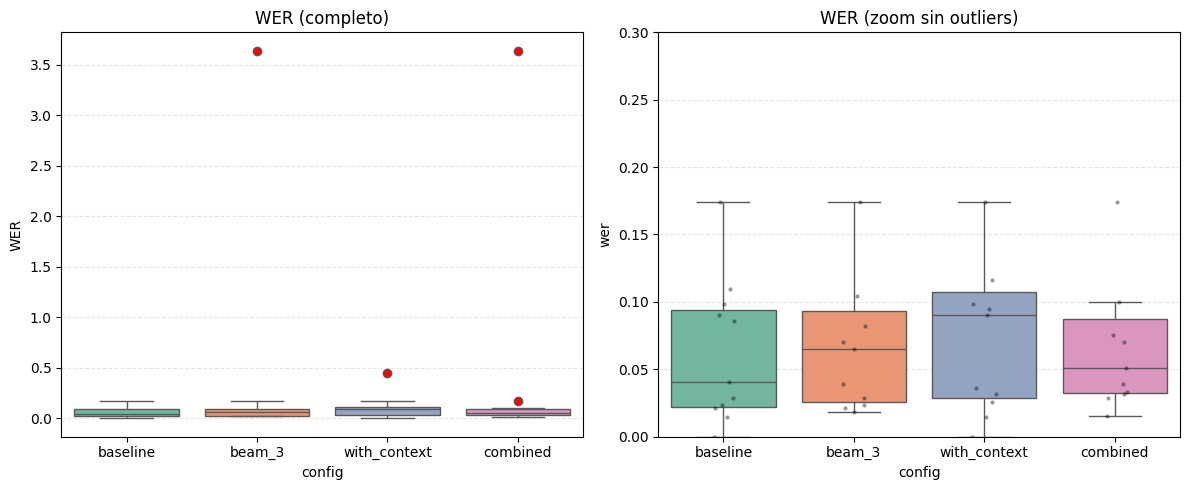

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico completo (outliers visibles)
sns.boxplot(
    data=df_long,
    x="config",
    y="wer",
    hue="config",
    palette="Set2",
    legend=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=6),
    ax=axes[0]
)

axes[0].set_title("WER (completo)")
axes[0].set_ylabel("WER")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)

# --- Gráfico zoom (zona útil)
sns.boxplot(
    data=df_long,
    x="config",
    y="wer",
    hue="config",
    palette="Set2",
    legend=False,
    showfliers=False,
    ax=axes[1]
)

sns.stripplot(
    data=df_long,
    x="config",
    y="wer",
    color="black",
    size=3,
    alpha=0.4,
    ax=axes[1]
)

axes[1].set_ylim(0, 0.3)
axes[1].set_title("WER (zoom sin outliers)")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 8.3 Selección de configuración óptima

Elijo la mejor configuración justificando por qué.

## 9. Implementación y ejecución del *pipeline* final de transcripción de audio

INTRODUCCION AQUI

### 9.1 Inicialización del entorno y gestión de rutas

En primer lugar, se define un mecanismo flexible para la gestión de rutas del proyecto, permitiendo localizar automáticamente la estructura de directorios y configurar las carpetas de entrada y salida. Este enfoque facilita la portabilidad del *pipeline*, evitando dependencias rígidas de entorno y permitiendo adaptar fácilmente la organización de datos sin modificar la lógica de procesamiento.

In [2]:
# Define las rutas del proyecto para el pipeline ASR
# Permite seleccionar la carpeta de entrada y fija la salida final del ASR
def configure_paths(
    base_data_dir: str = "data",
    input_folder: str = "processed",  # ahora relativo a audio/
    output_folder: str = "transcriptions"
) -> dict:

    project_root = Path.cwd()

    # Detectar raíz del proyecto
    while not (project_root / base_data_dir).exists():
        project_root = project_root.parent

    data_dir = project_root / base_data_dir

    # Carpeta base de audios
    audio_dir = data_dir / "audio"

    # Carpeta de entrada (processed o standardized)
    input_audio_dir = audio_dir / input_folder

    # Carpeta de transcripciones
    transcriptions_dir = data_dir / output_folder

    # Carpeta final del ASR (clave)
    asr_output_dir = transcriptions_dir / "asr_output"

    # Crear carpetas necesarias
    asr_output_dir.mkdir(parents=True, exist_ok=True)

    return {
        "project_root": project_root,
        "input_audio_dir": input_audio_dir,
        "asr_output_dir": asr_output_dir
    }

### 9.2 Implementación de funciones del *pipeline* de transcripción

A continuación, se implementan las distintas funciones que componen el *pipeline* de preprocesamiento. Cada función aborda una etapa específica del flujo de transformación de la señal, manteniendo una separación clara de responsabilidades. Este diseño modular permite analizar, validar y ajustar cada componente de forma independiente, favoreciendo tanto la comprensión del sistema como su mantenimiento y evolución.

#### 9.2.1 Carga del *dataset* de audios procesados

En esta fase se realiza la carga de los audios originales desde el sistema de almacenamiento, filtrando únicamente aquellos formatos válidos para su procesamiento. Posteriormente, se extraen metadatos básicos de cada archivo, como frecuencia de muestreo, número de canales y duración, que permiten caracterizar la señal. A partir de esta información, se generan indicadores (*flags*) que determinan las transformaciones necesarias para adaptar cada audio al formato objetivo requerido por el sistema ASR.

In [3]:
# Carga los audios desde el directorio de entrada
# Devuelve una lista de diccionarios con el identificador y la ruta de cada audio
def load_audio_dataset(
    input_audio_dir: Path,
    valid_extensions: set[str] = {".wav"}
) -> list[dict]:

    # Filtrado de archivos de audio válidos
    audio_files = [
        f for f in input_audio_dir.iterdir()
        if f.is_file() and f.suffix.lower() in valid_extensions
    ]

    # Verificación de existencia de audios
    if len(audio_files) == 0:
        raise FileNotFoundError("No se han encontrado audios válidos en el directorio de entrada")

    # Construcción del dataset con identificador y ruta
    dataset = [
        {
            "audio_id": f.stem,
            "path": f
        }
        for f in audio_files
    ]

    return dataset

#### 9.2.2 Inicialización del modelo ASR

Se realiza la carga de los archivos de audio desde el directorio de entrada, filtrando únicamente aquellos que presentan formatos válidos para su procesamiento. Esta etapa permite construir una representación inicial ligera del conjunto de datos, basada exclusivamente en las rutas de los archivos, facilitando su posterior tratamiento dentro del *pipeline*.

In [4]:
# Inicializa el modelo ASR con la configuración especificada
# Devuelve el modelo listo para ser utilizado en la transcripción
def load_asr_model(
    model_size: str = "medium",
    device: str = "cpu",
    compute_type: str = "int8"
):

    model = WhisperModel(
        model_size,
        device=device,
        compute_type=compute_type
    )

    return model

#### 9.2.3 Transcripción de audios

Una vez cargados los audios, se procede a la extracción de metadatos básicos que permiten caracterizar cada señal, incluyendo frecuencia de muestreo, número de canales y duración. A partir de esta información, se generan indicadores (*flags*) que determinan las transformaciones necesarias para adaptar cada audio al formato objetivo requerido por el sistema de reconocimiento automático del habla (ASR). La frecuencia de muestreo objetivo se fija en 16 kHz, garantizando la coherencia con los requisitos del modelo y evitando configuraciones inconsistentes en el *pipeline*.

In [5]:
# Aplica el modelo ASR para transcribir los audios del dataset
# Permite configurar parámetros de inferencia, con valores por defecto
def transcribe_audio_dataset(
    audio_dataset: list[dict],
    model,
    asr_params: dict = None
) -> list[dict]:

    # Definición de parámetros por defecto si no se proporcionan externamente
    if asr_params is None:
        asr_params = {
            "language": "es",                    # Fuerza el idioma español
            "beam_size": 1,                      # Decodificación greedy (rápida)
            "condition_on_previous_text": False, # Evita dependencia entre segmentos
            "word_timestamps": False,            # No se necesitan timestamps por palabra
            "temperature": 0.0                   # Salida determinista
        }

    results = []  # Lista donde se almacenarán las transcripciones

    # Iteración sobre cada audio con barra de progreso
    for item in tqdm(audio_dataset, desc="Transcribiendo audios"):

        # Ejecución del modelo ASR sobre el audio
        segments, _ = model.transcribe(
            str(item["path"]),  # Ruta del archivo de audio
            **asr_params        # Parámetros de inferencia
        )

        # Reconstrucción del texto completo a partir de los segmentos generados
        text = " ".join([seg.text for seg in segments]).strip()

        # Almacenamiento del resultado estructurado
        results.append({
            "audio_id": item["audio_id"],  # Identificador único del audio
            "text": text                   # Transcripción completa
        })

    return results  # Devuelve todas las transcripciones generadas

#### 9.2.4 Generación de salida estructurada

Una vez caracterizados los audios, se procede a su estandarización, transformando todos los archivos a un formato homogéneo (WAV, mono, 16 kHz). Este paso garantiza la compatibilidad con los modelos de reconocimiento automático del habla (ASR) y reduce la variabilidad asociada a diferencias en codificación, número de canales o frecuencia de muestreo. Asimismo, los audios estandarizados se almacenan en disco, permitiendo su reutilización en etapas posteriores sin necesidad de repetir este proceso.

In [6]:
# Guarda cada transcripción como un JSON independiente
def save_transcriptions_json(
    transcriptions: list[dict],
    output_dir: Path
) -> None:

    for item in transcriptions:
        output_path = output_dir / f"{item['audio_id']}.json"

        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(item, f, ensure_ascii=False, indent=4)

### 9.3 Ejecución del *pipeline* de transcripción de audio

Una vez definidas todas las funciones, se ejecuta el pipeline completo de forma secuencial. Este bloque coordina la aplicación ordenada de cada etapa sobre el conjunto de audios, desde su carga inicial hasta la generación de los archivos finales procesados. La estructura lineal del flujo facilita la comprensión del proceso global y permite verificar de forma clara la transformación progresiva de la señal a lo largo del pipeline.

En esta implementación se asume que el orden de los elementos en los datasets intermedios se mantiene constante a lo largo del flujo de procesamiento, lo que permite establecer una correspondencia directa entre las señales de audio y sus metadatos asociados. Esta decisión simplifica el diseño del pipeline en un contexto experimental. No obstante, en un entorno productivo, esta asociación debería realizarse mediante identificadores únicos que garanticen la trazabilidad y la robustez del sistema ante posibles desalineaciones.

In [7]:
print("Inicializando pipeline ASR...")

# Configuración de rutas
paths = configure_paths()
print("Rutas configuradas correctamente")

# Carga de audios
print("Cargando audios...")
audio_dataset = load_audio_dataset(paths["input_audio_dir"])
print(f"Audios encontrados: {len(audio_dataset)}")

# Inicialización del modelo
print("Inicializando modelo ASR...")
model_size = "medium"
device = "cpu"
compute_type = "int8"

model = load_asr_model(
    model_size=model_size,
    device=device,
    compute_type=compute_type
)
print("Modelo ASR cargado correctamente")

# Transcripción
print("Transcribiendo audios...")
results = transcribe_audio_dataset(audio_dataset, model)
print(f"Audios transcritos: {len(results)}")

# Ruta de salida (ya viene definida en configure_paths)
asr_output_dir = paths["asr_output_dir"]
print(f"Ruta de salida: {asr_output_dir}")

# Guardado
print("Guardando transcripciones...")
save_transcriptions_json(results, asr_output_dir)
print("Transcripciones guardadas correctamente")

print("Pipeline completado correctamente")

Inicializando pipeline ASR...
Rutas configuradas correctamente
Cargando audios...
Audios encontrados: 9
Inicializando modelo ASR...
Modelo ASR cargado correctamente
Transcribiendo audios...


Transcribiendo audios: 100%|██████████| 9/9 [02:00<00:00, 13.41s/it]

Audios transcritos: 9
Ruta de salida: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/asr_output
Guardando transcripciones...
Transcripciones guardadas correctamente
Pipeline completado correctamente


### 9.4 Validación del *pipeline* de transcripción de audio

En este apartado se realiza una verificación sistemática del comportamiento del pipeline una vez aplicadas todas las transformaciones. El objetivo es comprobar que la lógica condicional del VAD se ha ejecutado correctamente, garantizando que únicamente los audios clasificados como largos han sido modificados, mientras que los audios cortos permanecen invariantes. Para ello, se comparan las señales originales y procesadas en términos de duración y equivalencia de valores, permitiendo detectar posibles alteraciones no deseadas y validar la integridad del flujo de procesamiento antes de su uso en el módulo de transcripción automática.

In [9]:
# Verificación básica del pipeline de transcripción

print("\nIniciando validación...")

# Conteo
assert len(results) == len(audio_dataset), "Error: número de transcripciones no coincide"
print("✔ Conteo correcto")

# Estructura + contenido + unicidad
audio_ids = set()
empty_texts = []

for item in results:
    assert "audio_id" in item, "Error: falta 'audio_id'"
    assert "text" in item, "Error: falta 'text'"
    
    assert isinstance(item["text"], str), "Error: 'text' no es string"
    
    # Detección de textos vacíos (sin romper pipeline)
    if item["text"].strip() == "":
        empty_texts.append(item["audio_id"])
    
    # Unicidad
    assert item["audio_id"] not in audio_ids, f"audio_id duplicado: {item['audio_id']}"
    audio_ids.add(item["audio_id"])

print("✔ Estructura y contenido correctos")
print("✔ Unicidad de audio_id verificada")

# Reporte de textos vacíos
if empty_texts:
    print(f"⚠ Textos vacíos detectados: {len(empty_texts)}")
    print("Ejemplo:", empty_texts[:5])
else:
    print("✔ No se detectaron textos vacíos")

# Dataset limpio para etapas posteriores (opcional)
results_clean = [item for item in results if item["text"].strip() != ""]

print(f"✔ Registros válidos para NLP: {len(results_clean)}")

# Muestra para inspección
print("\n=== Muestra de transcripciones ===")
sample = pd.DataFrame(results).sample(n=min(5, len(results)), random_state=42)
display(sample)

print("✔ Validación completada correctamente")


Iniciando validación...
✔ Conteo correcto
✔ Estructura y contenido correctos
✔ Unicidad de audio_id verificada
✔ No se detectaron textos vacíos
✔ Registros válidos para NLP: 9

=== Muestra de transcripciones ===


,audio_id,text
7,2026-06-05T17_23_16_953Z_197950831620202_4dbacfc1,"Muy buenos días, mi nombre es Susana Aviles Gu..."
1,2026-05-31T15_36_30_720Z_216028298658042_8f69e405,"Mi nombre es José Castaya. Comentarles, infor..."
5,2026-06-04T16_49_43_585Z_266717569749192_451a3c62,Mi nombre es profesor Morán Reyes. Soy de la ...
0,2026-05-31T15_36_08_145Z_216028298658042_53b35098,Mi nombre es José Castaya. Justamente estamos...
8,2026-06-05T17_24_12_804Z_197950831620202_6a6fab16,"Bueno, mis nombres es Charre Javier Eliberto, ..."


✔ Validación completada correctamente


# QUEDA VALIDAR CON LOS 200 AUDIOS EN EL NOTEBOOK 2
- Buen WER = pipeline válido
- Buen WER en variedad = pipeline solido

## 10. Conclusiones
- Resumen del proceso aplicado
- Resultados principales
- Relevancia para el pipeline de Speech-to-Text